# The Gradient: Climbing the Mountain Fastest in the Fog

## Introduction: Problem Setup
Imagine a hiker is climbing a mountain in the fog. The hiker cannot see the whole landscape, but the hiker can feel the slope under your feet.

***Question**: Which direction should you step if your goal is simply to climb as quickly as possible?*

**Define the mountain**: It is a scalar-valued multivariable function $f(x,y)$. Assume it's mathematical expression is $$f(x,y)=x^2+2y^2$$

We use a contour map to represent the mountain's elevation from a bird's-eye view. Each contour line connects points that have the same elevation. Walking along one contour line means you stay at the same height, while moving across contour lines changes your elevation.

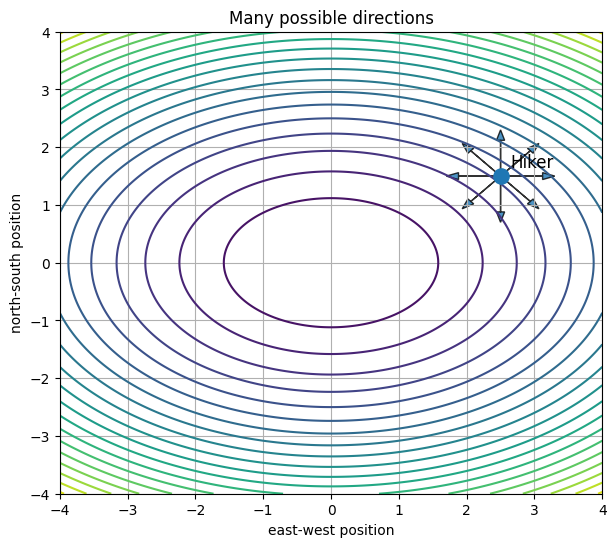

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Mountain height function
def f(x, y):
    return x**2 + 2*y**2

# Starting point
x0, y0 = 2.5, 1.5

# Create contour map
x = np.linspace(-4, 4, 300)
y = np.linspace(-4, 4, 300)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

plt.figure(figsize=(7, 6))

# Contour lines = same elevation lines
plt.contour(X, Y, Z, levels=20)

# Starting point
plt.scatter(x0, y0, s=120, zorder=5)
plt.text(x0 + 0.15, y0 + 0.15, "Hiker", fontsize=12)

# 8 possible directions
angles = np.linspace(0, 2*np.pi, 8, endpoint=False)
arrow_length = 0.8

for theta in angles:
    dx = arrow_length * np.cos(theta)
    dy = arrow_length * np.sin(theta)
    plt.arrow(
        x0, y0, dx, dy,
        head_width=0.12,
        length_includes_head=True,
        alpha=0.8
    )

plt.title("Many possible directions")
plt.xlabel("east-west position")
plt.ylabel("north-south position")
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.grid(True)
plt.show()

At this point on the mountain, the hiker has many possible directions to choose from.

Each arrow represents one small step the hiker could take.

But not all steps are equal:

- Some directions climb quickly.
- Some directions barely change elevation.
- Some directions go downhill.

So the key question is:

**Which direction gives the largest increase in height?**

### Definition of the Gradient
The gradient of a function $f$, denoted as $\nabla f$, is a vector that contains all its partial derivatives.

So for the function $f(x,y)=x^2+2y^2$, its gradient is $$\nabla f=\begin{bmatrix}
\frac{\delta f}{\delta x}\\
\frac{\delta f}{\delta y}\\
\end{bmatrix} = \begin{bmatrix}
2x\\
4y
\end{bmatrix}$$.

The gradient tells the hiker which direction leads to the steepest uphill climb. It is also perpendicular to the contour lines of $f$.

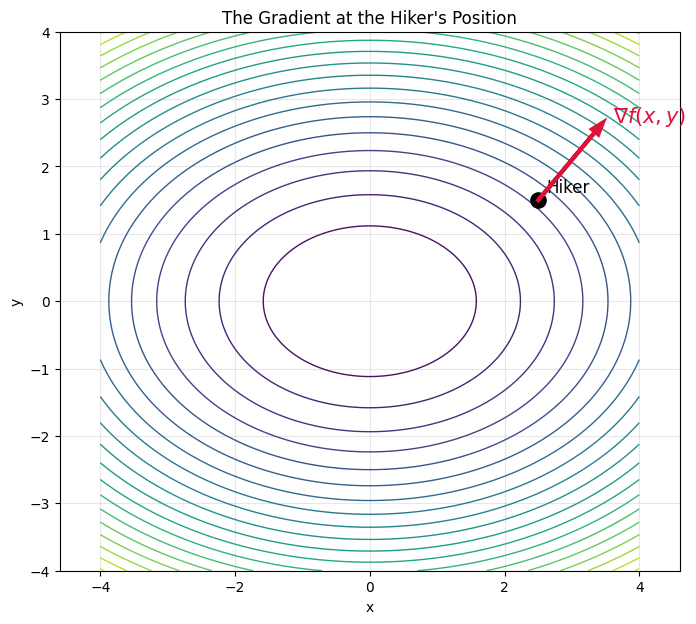

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Mountain
# -----------------------
def f(x, y):
    return x**2 + 2*y**2

def grad(x, y):
    return np.array([2*x, 4*y])

# -----------------------
# Same point as before
# -----------------------
x0, y0 = 2.5, 1.5

# Grid
x = np.linspace(-4, 4, 400)
y = np.linspace(-4, 4, 400)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

plt.figure(figsize=(8, 7))

# Contours
plt.contour(
    X,
    Y,
    Z,
    levels=20,

    linewidths=1
)

# Hiker
plt.scatter(x0, y0, color="black", s=120, zorder=5)
plt.text(x0+0.12, y0+0.12, "Hiker", fontsize=12)

# -----------------------
# Gradient
# -----------------------
g = grad(x0, y0)
g = g / np.linalg.norm(g)

arrow_length = 1.5

plt.arrow(
    x0,
    y0,
    arrow_length*g[0],
    arrow_length*g[1],
    color="crimson",
    linewidth=3,
    head_width=0.12,
    head_length=0.18,
    length_includes_head=True,
    zorder=10
)

plt.text(
    x0 + arrow_length*g[0] + 0.15,
    y0 + arrow_length*g[1],
    r"$\nabla f(x,y)$",
    fontsize=15,
    color="crimson",
    weight="bold"
)


plt.title("The Gradient at the Hiker's Position")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(alpha=0.3)

plt.show()

## Interactive Experiment: Climbing Race
Now let several hikers race uphill.

Each hiker starts at the same point.  
Each hiker takes the same step size.  
The only difference is the direction they choose.

Which hiker gains the most height?

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider

# Mountain height
def f(x, y):
    return x**2 + 2*y**2

# Gradient
def grad(x, y):
    return np.array([2*x, 4*y])

def unit(v):
    norm = np.linalg.norm(v)
    return v / norm if norm != 0 else v

def race_hikers(x0=2.5, y0=1.5, step_size=0.25, steps=8):
    hikers = {
        "Gradient": 0,
        "30° off": np.pi / 6,
        "60° off": np.pi / 3,
        "90° off": np.pi / 2,
        "Opposite": np.pi
    }

    paths = {}

    for name, angle_offset in hikers.items():
        path = np.zeros((steps + 1, 2))
        path[0] = [x0, y0]

        for i in range(steps):
            x, y = path[i]
            g = unit(grad(x, y))

            # rotate gradient direction by angle_offset
            R = np.array([
                [np.cos(angle_offset), -np.sin(angle_offset)],
                [np.sin(angle_offset),  np.cos(angle_offset)]
            ])

            direction = R @ g
            path[i + 1] = path[i] + step_size * direction

        paths[name] = path

    # contour map
    x = np.linspace(-5, 5, 400)
    y = np.linspace(-5, 5, 400)
    X, Y = np.meshgrid(x, y)
    Z = f(X, Y)

    plt.figure(figsize=(8, 7))
    plt.contour(X, Y, Z, levels=25,  linewidths=0.8)

    for name, path in paths.items():
        plt.plot(path[:, 0], path[:, 1], marker="o", label=name)

    plt.scatter(x0, y0, color="black", s=120, zorder=5)
    plt.text(x0 + 0.1, y0 + 0.1, "Start", fontsize=12)

    plt.title("Hiker Race: Which Direction Climbs Fastest?")
    plt.xlabel("x")
    plt.ylabel("y")
    #plt.axis("equal")
    plt.xlim(-5, 5)
    plt.ylim(-5, 5)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    print("Final heights:")
    for name, path in paths.items():
        final_x, final_y = path[-1]
        height = f(final_x, final_y)
        print(f"{name:10s}: {height:.3f}")

interact(
    race_hikers,
    x0=FloatSlider(value=2.5, min=-4, max=4, step=0.1, description="start x"),
    y0=FloatSlider(value=1.5, min=-4, max=4, step=0.1, description="start y"),
    step_size=FloatSlider(value=0.25, min=0.05, max=0.8, step=0.05, description="step size"),
    steps=IntSlider(value=8, min=1, max=20, step=1, description="steps")
);

The hiker following the gradient wins!

## Conclusion
From the experiment above, we discovered a natural strategy for climbing as quickly as possible: always follow the gradient.

But what if our goal is to reach the valley instead? In a future lesson, we'll learn about an optimization algorithm called gradient descent, which follows the opposite direction to efficiently find the lowest point of the mountain.